In [2]:
import matplotlib.pyplot as plt
import qutip
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

### Hamiltonian

We are going to simulate an input coherent state (freely traveling wave) coming from a bath (denoted by $\alpha$) interacting with a cavity (denoted by $\hat{a}$ operators). This cavity (which only supports one mode, aka the same mode as the signal) will then interact with the atom (two level system with operators represented by $\sigma$). There is no direct interaction of the traveling wave with the atom. Thus, we need an extra term to the Hamiltonian that relates bath (signal) to cavity. So, we have two types of waves to consider: the traveling wave from the bath and the standing wave formed in the cavity. The Hamiltonian is written as                                                                                                 

$$\hat{H} = \left (\kappa\alpha_{in}(t)\hat{a}^\dagger + \kappa^* \alpha_{in}^*(t)\hat{a} \right) + \left( g(t) \hat{a}\hat{\sigma}_+ + g^*(t) \hat{a}^\dagger \hat{\sigma}_- \right )$$

- $\hat{a}/\hat{a}^\dagger$: bosonic quantum operator in a cavity. 
- $\hat{\sigma_{\pm}} $: raising/lowering operators in the atom. Note: $\hat{\sigma}$ operators are always unitless. 
- $\kappa$ denotes the coupling between the bath and $\alpha_{in}$. Note this is the same $\kappa$ as in the decay terms which make sense because the decay terms come from the Hamiltonian. 
- The first term in the parentheses represents the coupling between the bath (where the signal originates from) and the cavity. The bath can carry multiple coherent states. Note: the bath term has different units from the cavity terms. 
- The second term in the parentheses describes the interaction between the cavity and the atom.

Note that we are only looking at the interaction Hamiltonian: the excess terms of $\hbar\omega_0 \hat{\sigma}_+ \hat{\sigma}_-$ and $\omega_c \hat{a}^\dagger \hat{a}$ are eliminated by transforming into the rotating frame (do this math). Also, the rotating wave approximation is applied here. 


#### Units Attention!
When I changed $\hat{a}$ from a bath operator to normal operator, the units of the $\hat{a}$ change from $\sqrt{Hz}$ to unitless as bath operators have unit of $\sqrt{Hz}$. Previously, $g$ had units of $\sqrt{Hz}$ to match Hamiltonian units (Hamiltonian has units of Hz). Now that $\hat{a}$ is unitless, g must have units of Hz. To do this transform, scale g by $\kappa$, which is determined by cavity parameters like cooperativity. We transform the coupling:
$$g_{\text{cav}} (t) = g_{\text{no cav}} (t) \cdot \frac{\kappa}{2} $$

$\kappa = \sqrt{\text{FWHM of cavity}}$, which defines the cavity bandwidth and therefore the acceptance of the input signal. This in essence is tailoring the cavity/bath coupling by defining a cavity bandwidth, which determines the acceptance of the input signal. For example, if the input signal is too high bandwidth, it will be rejected by the cavity. Thus, we need to send in signals considered "slow" to the cavity. As an example, if $\kappa=1$, that means the FWHM of the cavity is 1 Hz. Thus, if the Gaussian pulse occurs over a time range of less than 1 second, it might not get into the cavity. 

### Decay Terms
Using the SLH formalism, the "quantum" terms are in the Lindblad vector (i.e. no bath terms exist, they have been factored out). The decay terms are then given by cavity relaxation (whose rate is denoted by $\kappa$). We assume no thermal photons because at least for 780 nm, the thermal background is negligible.

$$ L = [\kappa \hat{a}] $$

We do not include a spontaneous decay term $g(t)\hat{\sigma}_-$ because the atom will decay into the cavity rather than into an incoherent decay channel (free space). More formally, the $\hat{\sigma}$ terms are not bathlike so they don't show up in the Lindblad terms, which include the bath terms.

Would have 1/C on the lindblad term in reality (high cooperativity suppresses collapse, with low cooperativity the term is not suppressed)

Read SLH 7.2.2.

In [54]:
def plot(time, alpha, g_vals, a_ground, a_excited, n_cavity, S_expect):
    # Plot alpha and g
    plt.figure(figsize=(5, 3))
    plt.plot(time, alpha/np.max(alpha), label=r"$\alpha_{in}(t)$ (normalized)")
    plt.plot(time, g_vals/np.max(g_vals), label="g(t) (normalized)")
    plt.legend(); plt.grid()

    fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    axs[0,0].plot(time, a_ground, label="Ground State Probability")
    axs[0,0].set_title("Ground State Probability")
    axs[0,0].grid(True)

    axs[0,1].plot(time, a_excited, label="Excited State Probability")
    axs[0,1].set_title("Excited State Probability")
    axs[0,1].grid(True)

    axs[1,0].plot(time, n_cavity, label="Cavity photon number")
    axs[1,0].set_title("Cavity photon number")
    axs[1,0].grid(True)

    axs[1,1].plot(time, abs(S_expect), label="<S>")
    axs[1,1].set_title("S")
    axs[1,1].grid(True) 

    for ax in axs.flat:
        ax.set(xlabel="Time")

    fig.tight_layout()
    plt.show()

$$\hat{H} = \left ( \kappa\alpha_{in}(t)\hat{a}^\dagger + \kappa^* \alpha_{in}^*(t)\hat{a} \right) + \left( g(t) \hat{a}\hat{\sigma}_+ + g^*(t) \hat{a}^\dagger \hat{\sigma}_- \right )

= (H_1 + H_2) + (H_3 + H_4)$$

In [ ]:
def tls_cavity_simulate(alpha_in, T, kappa, sigma, mu, N):
    time = np.linspace(0, T, N)
    alpha = alpha_in(time)

    ### TEMPLATE FUNCTION (k(t) = template at time t)
    def k(t):
        a = np.sqrt(1/(sigma*np.sqrt(np.pi))) # for normalized area
        return a * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian

    ### COUPLING FUNCTION (g(t) = coupling strength between atom and light at time t)
    def g(t):
        integral_value, _ = integrate.quad(lambda x: np.abs(k(x))**2, 0, t) # Denominator -inf to t
        return k(t)*(kappa/2) / np.sqrt(integral_value) if integral_value > 0 else 0 # kappa

    g_vals, k_vals = [], []
    for t in time: 
        g_vals.append(g(t)) 
        k_vals.append(k(t))

    #print("Area of template k(t):", integrate.simps(np.array(k_vals)**2, time))
    g_vals_smoothed = gaussian_filter1d(g_vals, sigma=10)  # Apply Gaussian smoothing
    def g_smoothed(t):
        if t == time[0]: return 0
        else:            return np.interp(t, time, g_vals_smoothed)  # Interpolate smoothed g values

    # ----------- OPERATORS ------------ 
    N = 10  # dimension of Hilbert space for Fock states
    a = qutip.tensor(qutip.destroy(N), qutip.qeye(2)) # Annihilation operator for cavity (acts trivally on the atom) 
    sm = qutip.tensor(qutip.qeye(N), qutip.sigmam()) # Lowering operator for the atom
    sp = qutip.tensor(qutip.qeye(N), qutip.sigmap()) # Raising operator for the atom

    # ----------- HAMILTONIAN -----------
    H1 = a.dag() 
    H2 = a 
    def H1_coeff(t, args): 
        return kappa*alpha_in(t) 
    def H2_coeff(t, args): 
        return np.conjugate(kappa)*np.conjugate(alpha_in(t))

    H3 = a*sp
    H4 = a.dag()*sm
    def H3_coeff(t, args): 
        return g_smoothed(t)
    def H4_coeff(t, args): 
        return np.conjugate(g_smoothed(t))

    H = [[H1, H1_coeff], [H2, H2_coeff], [H3, H3_coeff], [H4, H4_coeff]] # Final Hamiltonian

    # DISSIPATION OPERATORS (collapse operators)
    c_op_list = [kappa*a]  # time-dependent collapse term

    # --------- EXPECTATION VALUES ---------
    e_ee = sp*sm # |e><e|
    e_gg = sm*sp # |g><g|
    S = sm # |g><e| 
    e_ops=[a.dag()*a, e_ee, e_gg, S] # expectation values we want (of the bath operator to get alpha)

    psi0 = tensor(basis(N, 0), basis(2, 1)) # Starting atom in ground state

    ### SIMULATE: Solve Lindblad master equation 
    result = mesolve(H, psi0, time, c_op_list, e_ops=e_ops) 
    n_cavity, a_excited, a_ground, S_expect = result.expect[0], result.expect[1], result.expect[2], result.expect[3]

    return time, alpha, g_vals, n_cavity, a_excited, a_ground, S_expect

## Summary (most up to date)

$$\hat{H} = \left (\kappa\alpha_{in}(t)\hat{a}^\dagger + \kappa^* \alpha_{in}^*(t)\hat{a} \right) + \left( g(t) \hat{a}\hat{\sigma}_+ + g^*(t) \hat{a}^\dagger \hat{\sigma}_- \right )$$
$$ L = [\kappa \hat{a}] $$
- $\hat{a}$ is unitless, $\hat{\sigma}$ are unitless. 
- $\kappa = \sqrt{\text{FWHM}_{cavity}}$, which defines the cavity bandwidth and therefore the acceptance of the input signal. 
    - Cavity bandwidth = $\frac{1}{FWHM} \to$ pulse duration must be $> \frac{1}{FWHM} = 1/\kappa^2$
    - Example: If $\kappa=1$, the FWHM of the cavity is 1 Hz. If the Gaussian pulse duration is shorter than 1 second, it might not get accepted into the cavity. 

Note that because we are now in a cavity:
$$g(t)=g_{\text{cav}}(t) = \frac{g_{\text{no cav}}(t)}{2} \cdot \frac{\kappa}{2} $$

This relation can be fully derived from the optomechanics paper + cooperativity notes (see Jeff). 
- $g_{\text{cav}}(t)$ is under amplitude scaling (units $\text{Hz}$)
- $g_{\text{no cav}}(t)$ is under power scaling (units $\sqrt{\text{Hz}}$). 
- $\kappa$ is under power scaling because $\alpha_{in}$ is a bath term (units $\sqrt{\text{Hz}}$).
- Amplitude $\to$ power scaling: multiply by factor of 2

### Cases
- When we start the atom in an excited state, $k=0$ (thus no decay) and $g$ is constant, we see Rabi oscillations.
- When we start the atom in an excited state, $k=0.1$ and $g$ is constant, we see decaying Rabi oscillations.

- When we start the atom in an ground state, $k=0$ and $g$ is constant, we see nothing happening.
- When we start the atom in an ground state, $k=0.1$ and $g$ is constant, weird behavior. I'd expect nothing to happen but perhaps the creation term in the Hamiltonian adds something?

We expect the cavity photon number increases then decreases as the atom absorbs the signal and spins up (and stays). When $g$ is constant, there will be Rabi oscillations between the cavity and atom. 

Minimum pulse duration:  0.25


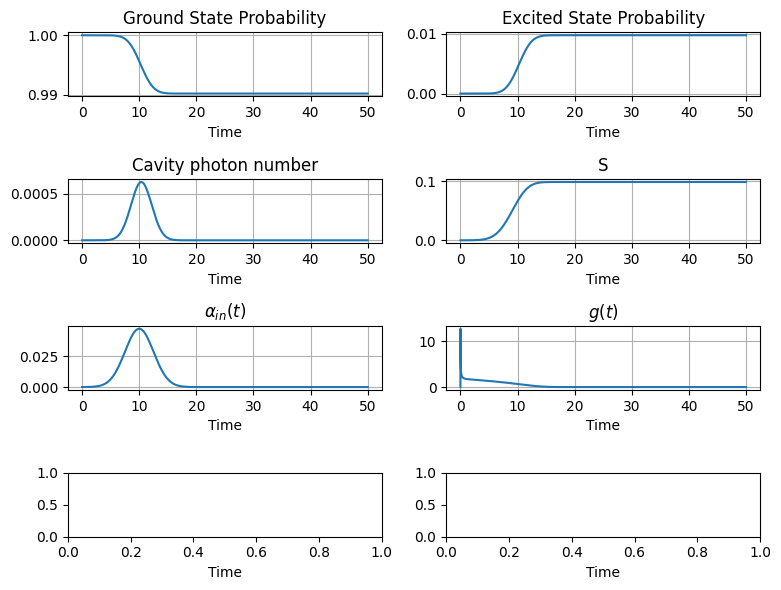

0.009789587912320034


In [31]:
### --------- INPUT SIGNAL ---------
T = 50 # total time 
mu, sigma = 10, 2.5 
amplitude = 0.1*np.sqrt(1/(sigma*np.sqrt(np.pi))) # small amplitude
def alpha_in(t):
    return amplitude * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian input
kappa = 2
print('Minimum pulse duration: ', 1/(kappa**2)) # must be larger than this by a certain amount (can also increase sigma)

time, alpha, g_vals, n_cavity, a_excited, a_ground, S_expect = tls_cavity_simulate(alpha_in, T, kappa, sigma, mu, N=8000)
plot(time, alpha, g_vals, a_ground, a_excited, n_cavity, S_expect)
print(a_excited[-1])

### Input bandwidth signals
Test different input bandwidth signals until we see it is rejected by the cavity. Change $\kappa$ until it can maximize the excited state population. As discussed above, $\kappa$ defines how much the of the input signal can be accepted by the cavity: the rest is lost by the cavity. 

In [48]:
def get_pulse_duration(alpha_in, time, threshold=0.01):
    max_amplitude = np.max(np.abs(alpha_in(time)))
    significant_indices = np.where(np.abs(alpha_in(time)) > threshold * max_amplitude)[0]
    if len(significant_indices) == 0:
        return 0, 0
    t_start = time[significant_indices[0]]
    t_end = time[significant_indices[-1]]
    duration = t_end - t_start

    return t_start, t_end, duration

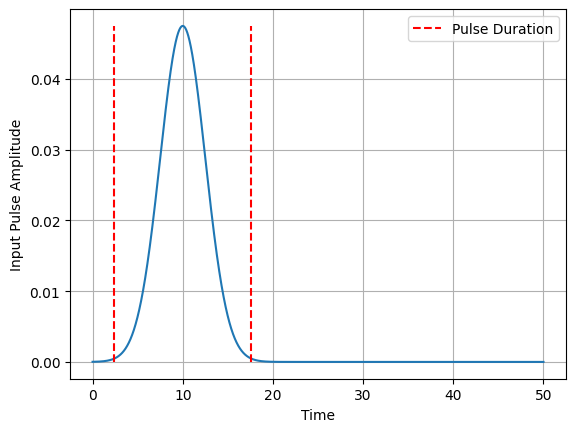

In [49]:
time = np.linspace(0, T, 8000)
alpha = alpha_in(time)
t_start, t_end, duration = get_pulse_duration(alpha_in, time)

plt.plot(time, alpha_in(time))
plt.vlines([t_start, t_end], 0, max(alpha), color='red', linestyle='--', label='Pulse Duration')
plt.xlabel('Time')
plt.ylabel('Input Pulse Amplitude')
plt.legend()
plt.grid()

In [45]:
a_excited_vals = []
kappa_vals = np.linspace(0.5, 10, 30)
for i in tqdm(range(len(kappa_vals))):
    time, alpha, g_vals, n_cavity, a_excited, a_ground, S_expect = tls_cavity_simulate(alpha_in, T, kappa_vals[i], sigma, mu, N=8000)
    a_excited_vals.append(a_excited[-1])

100%|██████████| 30/30 [04:38<00:00,  9.27s/it]


Pulse duration must be $> \frac{1}{FWHM} = \frac{1}{\kappa^2}$, so $\kappa > \sqrt{\frac{1}{\text{pulse duration}}}$

### To do: 
Analytically compute this trend (lorentzian/gaussian overlap based on incoming signal?)
Overlap diagram that Lee drew, becomes an overlap integral weighted by the lorentzian

$\int_{-\infty}^\infty |k_{gauss}|^2 |L(t)|^2 dt$

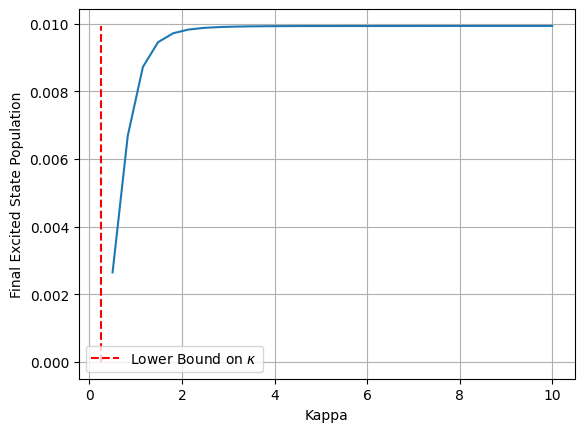

In [47]:
plt.plot(kappa_vals, a_excited_vals)
plt.vlines([np.sqrt(1/duration)], 0, max(a_excited_vals), color='red', linestyle='--', label=r'Lower Bound on $\kappa$')
plt.xlabel('Kappa')
plt.ylabel('Final Excited State Population')
plt.legend()
plt.grid()

Alternatively, fix $\kappa$ and adjust the input pulse until it is slow enough to match the bandwidth of the cavity:
$$\text{Pulse duration} > \frac{1}{\kappa^2}$$

Note: some things are adjusted to ensure that the entire $\alpha_{in}$ can fit within the time frame. 

In [59]:
mu, sigma = 30, 5
kappa=2
T = 60
amplitude = 0.1*np.sqrt(1/(sigma*np.sqrt(np.pi))) # small amplitude
def alpha_in(t):
    return amplitude * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian input

time, alpha, g_vals, n_cavity, a_excited, a_ground, S_expect = tls_cavity_simulate(alpha_in, T, kappa, sigma, mu, N=8000)
#plot(time, alpha, g_vals, a_ground, a_excited, n_cavity, S_expect)

In [66]:
# Fix kappa
kappa = 2
print('Minimum pulse duration: ', 1/(kappa**2)) # must be larger than this by a certain amount (can also increase sigma)

a_excited_vals2 = []
sigma_vals = np.linspace(0.1, 8, 30)
T = 80
time = np.linspace(0, T, 8000)
pulse_durations = []
for i in tqdm(range(len(sigma_vals))):
    mu, sigma = 30, sigma_vals[i] 
    amplitude = 0.1*np.sqrt(1/(sigma*np.sqrt(np.pi))) # small amplitude
    def alpha_in(t):
        return amplitude * np.exp(-((t-mu)**2) / (2*sigma**2)) # Gaussian input
    
    time, alpha, g_vals, n_cavity, a_excited, a_ground, S_expect = tls_cavity_simulate(alpha_in, T, kappa, sigma, mu, N=8000)
    t_start, t_end, duration = get_pulse_duration(alpha_in, time) # get the pulse duration for this sigma

    pulse_durations.append(duration)
    a_excited_vals2.append(a_excited[-1])

Minimum pulse duration:  0.25


100%|██████████| 30/30 [06:41<00:00, 13.38s/it]


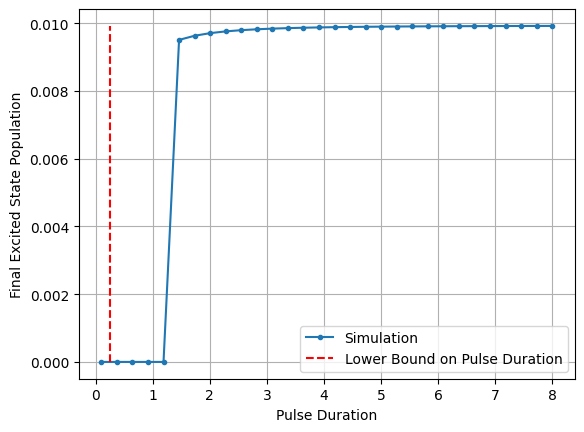

In [67]:
plt.plot(sigma_vals, a_excited_vals2, '.-', label='Simulation')
plt.vlines([1/kappa**2], 0, max(a_excited_vals2), color='red', linestyle='--', label=r'Lower Bound on Pulse Duration')
plt.xlabel('Pulse Duration')
plt.ylabel('Final Excited State Population')
plt.legend()
plt.grid()

This jump is quite weird: I wasn't expecting it to be as sharp as it is. I plotted in finer detail below (restricting the range of pulse durations) but seems to still be a sharp jump. 

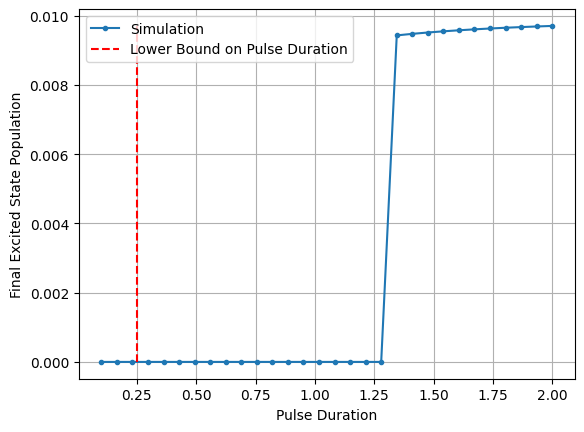